<a href="https://colab.research.google.com/github/dashgaming952-cloud/google-colab/blob/main/launch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
ls /content/drive/MyDrive


 000062.jpg
 0aa095c3-9d4d-4416-8788-82655af859a8.jpg
 0e240297-2265-411e-b386-cb59a44f98ae.jpg
 1bb71a5d-a665-4d72-9e06-b7892a8a7e92.jpg
 5a840d5b-f861-482c-9ea3-fc7a30f4834b.jpg
 bbox_result_val.pkl
 beigejogger.jpg
 beigepant.jfif
 blackjeans2.jpeg
 blackjeans.jfif
 blacktshirt.jpg
 bluegurkha2.jpeg
 bluegurkha.jpeg
 bluejeansbgr.png
 bluejeans.jpg
 bluetrack2.jpg
 bluetrack.jpg
'Change "major " to " titan".gdoc'
 chatgptfullsleeve.webp
 chatgptshirt.webp
 checkshirt.jpg
'Colab Notebooks'/
 hrnet_for_landmark/
 IMG-20250603-WA0035.jpg
'jogger[1].jpg'
 LONG-SLEEVE-TEE-FRONT-01_2000x.webp
'maroonshirt[1].jpg'
 musadeeqbgr.png
 musadeeqpant.jpeg
 orangetshirt.webp
 pinkpant.jpg
 pinktrack.jpg
'pose_hrnet-w48_384x288-deepfashion2_mAP_0.7017 (1).pth'
'purple_tshirt[1].jpg'
'stripeshirt[1].jpg'
'WhatsApp Image 2026-01-01 at 8.42.01 PM.jpeg'
 whiteshort.jpg


In [ ]:
!rsync -a --info=progress2 "/content/drive/MyDrive/hrnet_for_landmark/hrnet-fashion/" "/content/HRNet-for-Fashion-Landmark-Estimation.PyTorch/"


      4,213,137  30%   15.06kB/s    0:04:33 (xfr#374, to-chk=615/1062)

In [ ]:
%cd HRNet-for-Fashion-Landmark-Estimation.PyTorch


In [ ]:
!pip install yacs opencv-python matplotlib tqdm pycocotools
%cd lib
!make
%cd ..


In [13]:
!mkdir -p models
!mkdir -p models
!mv "/content/drive/MyDrive/pose_hrnet-w48_384x288-deepfashion2_mAP_0.7017 (1) (1).pth" \
    "models/pose_hrnet-w48_384x288-deepfashion2_mAP_0.7017.pth"
!ls models

pose_hrnet-w48_384x288-deepfashion2_mAP_0.7017.pth


In [14]:
import sys
import types
import os

ROOT = "/content/HRNet-for-Fashion-Landmark-Estimation.PyTorch"
LIB_MODELS_PATH = os.path.join(ROOT, "lib", "models")

# Create empty module called "models"
models_module = types.ModuleType("models")
models_module.__path__ = [LIB_MODELS_PATH]

# Register it
sys.modules["models"] = models_module

print("Fake 'models' package created and linked")
import sys
import importlib

# import lib.models first
lib_models = importlib.import_module("lib.models")

# alias it as "models"
sys.modules["models"] = lib_models

print("models → lib.models alias created")
from lib.config import cfg
from lib.config import update_config
from lib.models.pose_hrnet import get_pose_net
from lib.core.inference import get_final_preds
from lib.utils.transforms import get_affine_transform
class Args:
    cfg = "experiments/deepfashion2/hrnet/w48_384x288_adam_lr1e-3.yaml"
    opts = []

args = Args()
class Args:
    def __init__(self):
        self.cfg = "experiments/deepfashion2/hrnet/w48_384x288_adam_lr1e-3.yaml"
        self.opts = []
        self.modelDir = ""
        self.logDir = ""
        self.dataDir = ""

args = Args()
print("Args object created")
from lib.config import cfg, update_config

update_config(cfg, args)
cfg.freeze()

print("Config loaded successfully")
from lib.models.pose_hrnet import get_pose_net
import torch

model_path = "models/pose_hrnet-w48_384x288-deepfashion2_mAP_0.7017.pth"

model = get_pose_net(cfg, is_train=False)
model.load_state_dict(torch.load(model_path))
model = model.cuda()
model.eval()

print("HRNet model loaded successfully 🚀")


Fake 'models' package created and linked
models → lib.models alias created
Args object created
Config loaded successfully
HRNet model loaded successfully 🚀


Detected joints: 294


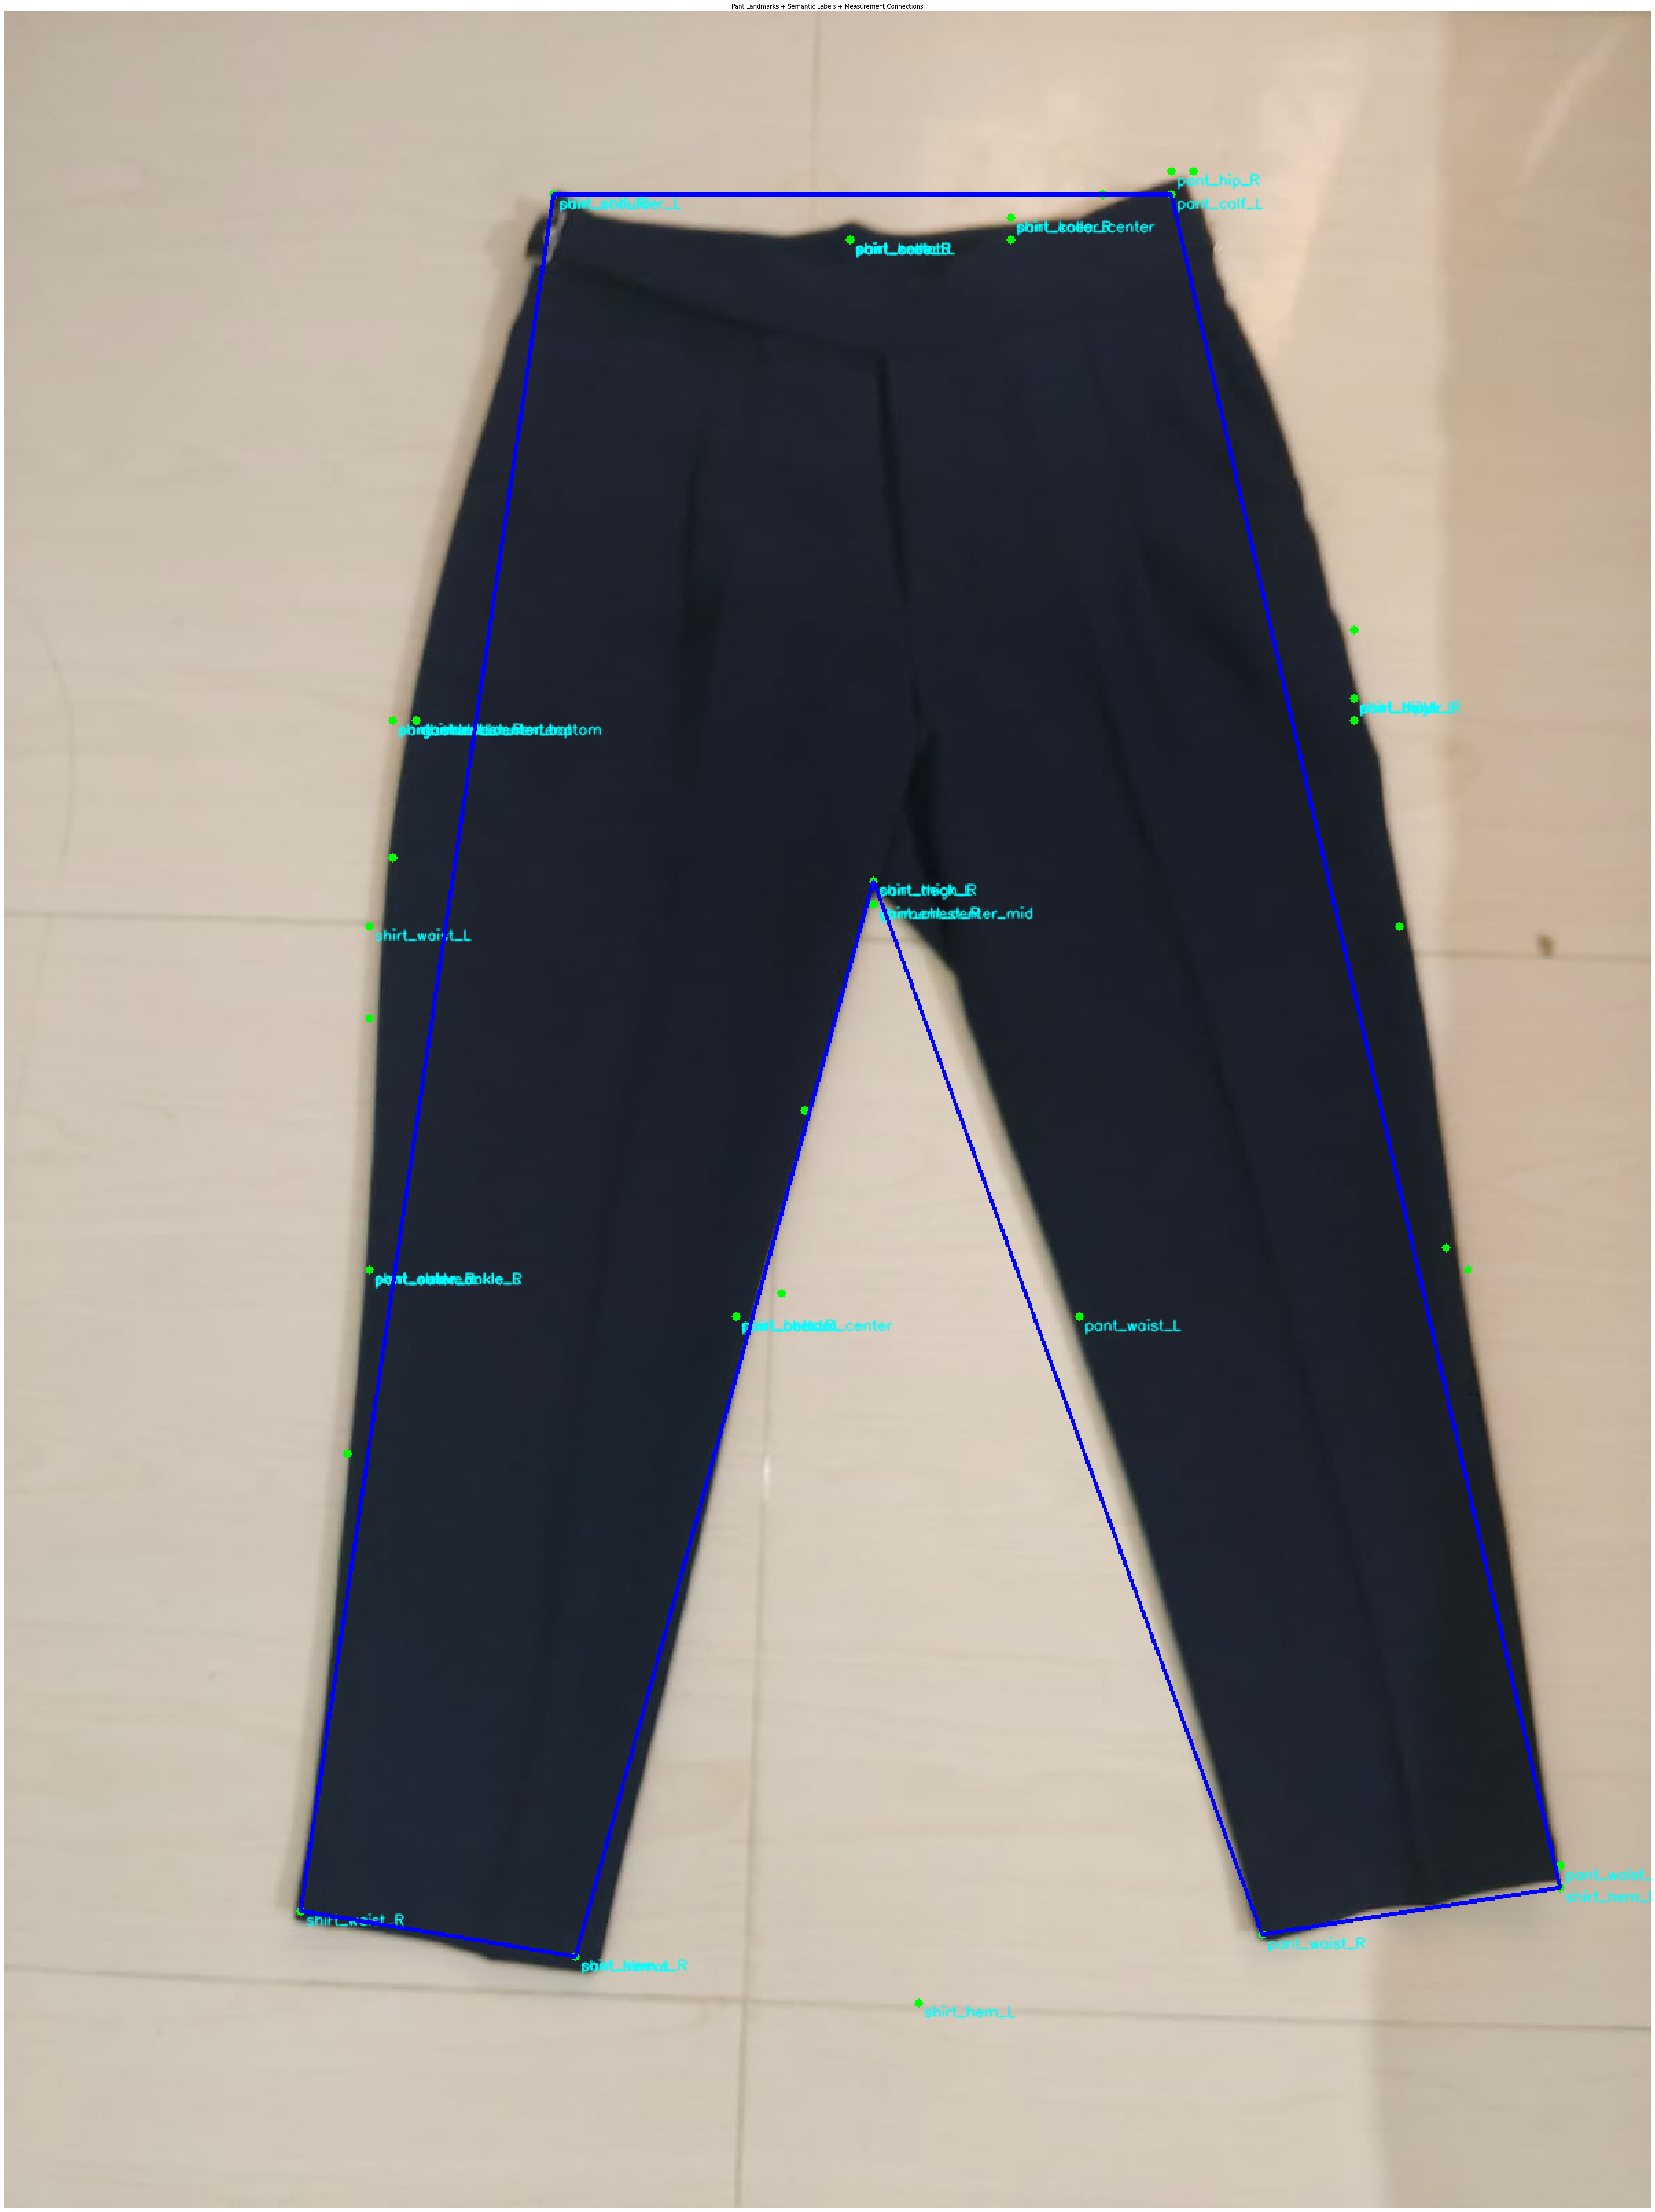

In [30]:
# ======================================================
# HRNet + Numbered Points + Semantic Labels + Connections
# ======================================================

import sys, cv2, torch, argparse
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------
# PATHS
# ------------------------------------------------------
HRNET_ROOT = "/content/HRNet-for-Fashion-Landmark-Estimation.PyTorch"
CFG_FILE   = f"{HRNET_ROOT}/experiments/deepfashion2/hrnet/w48_384x288_adam_lr1e-3.yaml"
MODEL_FILE = f"{HRNET_ROOT}/models/pose_hrnet-w48_384x288-deepfashion2_mAP_0.7017.pth"

IMAGE_PATH = "/content/drive/MyDrive/bluegurkha.jpeg"

# ------------------------------------------------------
# IMPORT HRNET
# ------------------------------------------------------
sys.path.append(f"{HRNET_ROOT}/lib")
from config import cfg, update_config
import models

# ------------------------------------------------------
# LOAD CONFIG
# ------------------------------------------------------
args = argparse.Namespace(
    cfg=CFG_FILE,
    opts=[],
    modelDir='',
    logDir='',
    dataDir='',
    prevModelDir=''
)
update_config(cfg, args)

# ------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------
model = models.pose_hrnet.get_pose_net(cfg, is_train=False)
model.load_state_dict(torch.load(MODEL_FILE, map_location="cpu"), strict=False)
model.eval()

# ------------------------------------------------------
# LOAD IMAGE
# ------------------------------------------------------
img = np.array(Image.open(IMAGE_PATH).convert("RGB"))
H, W = img.shape[:2]

# ------------------------------------------------------
# HRNET PREPROCESS
# ------------------------------------------------------
inp = cv2.resize(img, (288, 384))
inp = inp.astype(np.float32) / 255.0
inp = inp.transpose(2, 0, 1)
inp = torch.from_numpy(inp).unsqueeze(0)

# ------------------------------------------------------
# INFERENCE
# ------------------------------------------------------
with torch.no_grad():
    output = model(inp)

heatmaps = output.squeeze(0).cpu().numpy()
num_joints = heatmaps.shape[0]
hm_h, hm_w = heatmaps.shape[1:]

print("Detected joints:", num_joints)

# ------------------------------------------------------
# EXTRACT + SORT POINTS
# ------------------------------------------------------
points = []

for jid in range(num_joints):
    hm = heatmaps[jid]
    y, x = np.unravel_index(np.argmax(hm), hm.shape)
    x_img = int(x * W / hm_w)
    y_img = int(y * H / hm_h)
    points.append((jid, x_img, y_img))

points = sorted(points, key=lambda x: x[0])

POINT_DICT = {jid: (x, y) for jid, x, y in points}

# ------------------------------------------------------
# SEMANTIC GARMENT JOINT MAP (YOUR MAP)
# ------------------------------------------------------
GARMENT_JOINT_MAP = {
    # ---------- SHIRT ----------
    0:  "shirt_collar_L",
    1:  "shirt_collar_R",
    2:  "shirt_neck_L",
    3:  "shirt_neck_R",
    4:  "shirt_collar_center",
    6:  "shirt_shoulder_L",
    7:  "shirt_shoulder_R",
    8:  "shirt_sleeve_L",
    9:  "shirt_sleeve_R",
    10: "shirt_chest_L",
    11: "shirt_chest_R",
    12: "shirt_chest_center",
    13: "shirt_waist_L",
    14: "shirt_waist_R",
    15: "shirt_hem_L",
    16: "shirt_hem_R",

    # ---------- PANTS ----------
    20: "pant_waist_L",
    21: "pant_waist_R",
    22: "pant_waist_center",
    23: "pant_hip_L",
    24: "pant_hip_R",
    25: "pant_crotch",
    26: "pant_thigh_L",
    27: "pant_thigh_R",
    28: "pant_knee_L",
    29: "pant_knee_R",
    30: "pant_calf_L",
    31: "pant_calf_R",
    32: "pant_ankle_L",
    33: "pant_ankle_R",
    34: "pant_outer_ankle_L",
    35: "pant_outer_ankle_R",
    36: "pant_hem_L",
    37: "pant_hem_R",
    38: "pant_bottom_center",

    # ---------- GLOBAL ----------
    39: "garment_center_top",
    40: "garment_center_mid",
    41: "garment_center_bottom"

}

# ------------------------------------------------------
# 🔴 YOUR MANUAL INDICES (AS BEFORE)
# ------------------------------------------------------
WAIST_L        = 6
WAIST_R        = 30
OUTER_ANKLE_L  = 14
OUTER_ANKLE_R  = 16
INNER_ANKLE_L  = 9
INNER_ANKLE_R  = 21
INSEAM         = 27

CONNECTIONS = [
    (WAIST_L, OUTER_ANKLE_L),
    (WAIST_R, OUTER_ANKLE_R),
    (WAIST_L, WAIST_R),
    (INNER_ANKLE_L, OUTER_ANKLE_L),
    (INNER_ANKLE_R, OUTER_ANKLE_R),
    (INNER_ANKLE_L, INSEAM),
    (INNER_ANKLE_R, INSEAM),
]

# ------------------------------------------------------
# DRAW POINTS + NUMBERS + SEMANTIC LABELS + LINES
# ------------------------------------------------------
draw = img.copy()

for idx, (jid, x, y) in enumerate(points, start=1):
    cv2.circle(draw, (x, y), 3, (0, 255, 0), -1)

    # numeric label (small)
    #cv2.putText(
       # draw,
       # str(idx),
        #(x + 2, y - 2),
        #cv2.FONT_HERSHEY_SIMPLEX,
       # 0.25,
       # (255, 0, 0),
        #1,
        #cv2.LINE_AA
   # )

    # semantic label (only if defined)
    if jid in GARMENT_JOINT_MAP:
        cv2.putText(
            draw,
            GARMENT_JOINT_MAP[jid],
            (x + 4, y + 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (0, 255, 255),
            1,
            cv2.LINE_AA
        )

# draw connections
for a, b in CONNECTIONS:
    if a in POINT_DICT and b in POINT_DICT:
        cv2.line(draw, POINT_DICT[a], POINT_DICT[b], (0, 0, 255), 2)

# ------------------------------------------------------
# SHOW RESULT
# ------------------------------------------------------
plt.figure(figsize=(60, 100))
plt.imshow(draw)
plt.axis("off")
plt.title("Pant Landmarks + Semantic Labels + Measurement Connections")
plt.show()



In [31]:
# ==============================
# 1️⃣ ASK USER FIRST
# ==============================
unit = "in"

user_input = input(
    "Enter waist size (FULL circumference).\n"
    "Press ENTER to skip: "
).strip()

c_val = float(user_input) if user_input != "" else None


# ==============================
# 2️⃣ MEASUREMENT DEFINITIONS
# ==============================
MEASURE_LINES = {
    "waist":          (WAIST_L, WAIST_R),

    "outseam_left":   (WAIST_L, OUTER_ANKLE_L),
    "outseam_right":  (WAIST_R, OUTER_ANKLE_R),

    "ankle_left":     (INNER_ANKLE_L, OUTER_ANKLE_L),
    "ankle_right":    (INNER_ANKLE_R, OUTER_ANKLE_R),

    "inseam_left":    (INNER_ANKLE_L, INSEAM),
    "inseam_right":   (INNER_ANKLE_R, INSEAM),
}


# ==============================
# 3️⃣ SAFE PIXEL FETCH
# ==============================
def get_px(pair):
    if pair in line_pixel_counts:
        return line_pixel_counts[pair]
    rev = (pair[1], pair[0])
    if rev in line_pixel_counts:
        return line_pixel_counts[rev]
    return None


# ==============================
# 4️⃣ EXTRACT PIXEL VALUES
# ==============================
waist_px = get_px(MEASURE_LINES["waist"])

outseam_L_px = get_px(MEASURE_LINES["outseam_left"])
outseam_R_px = get_px(MEASURE_LINES["outseam_right"])

ankle_L_px   = get_px(MEASURE_LINES["ankle_left"])
ankle_R_px   = get_px(MEASURE_LINES["ankle_right"])

inseam_L_px  = get_px(MEASURE_LINES["inseam_left"])
inseam_R_px  = get_px(MEASURE_LINES["inseam_right"])


# ==============================
# 5️⃣ AVERAGING (LEFT / RIGHT)
# ==============================
def avg(a, b):
    return (a + b) / 2 if a is not None and b is not None else None

outseam_px = avg(outseam_L_px, outseam_R_px)
ankle_px   = avg(ankle_L_px, ankle_R_px)
inseam_px  = avg(inseam_L_px, inseam_R_px)


# ==============================
# 6️⃣ SAFE RATIOS
# ==============================
def safe_ratio(num, den):
    return num / den if num is not None and den is not None else None

ratio_waist_outseam = safe_ratio(outseam_px, waist_px)
ratio_waist_ankle   = safe_ratio(ankle_px, waist_px)
ratio_waist_inseam  = safe_ratio(inseam_px, waist_px)

print("\n----- RATIOS -----")
print("ratio waist → outseam :", ratio_waist_outseam)
print("ratio waist → ankle  :", ratio_waist_ankle)
print("ratio waist → inseam :", ratio_waist_inseam)


# ==============================
# 7️⃣ ESTIMATE REAL MEASUREMENTS
# ==============================
if c_val is not None and waist_px is not None:

    half_waist = c_val / 2  # flat waist → half circumference

    est_outseam = (
        ratio_waist_outseam * half_waist - 2
        if ratio_waist_outseam is not None else None
    )

    est_ankle = (
        ratio_waist_ankle * half_waist
        if ratio_waist_ankle is not None else None
    )

    est_inseam = (
        ratio_waist_inseam * half_waist
        if ratio_waist_inseam is not None else None
    )

    print(f"\n----- ESTIMATES (based on waist = {c_val} {unit}) -----")
    if est_outseam is not None:
        print(f"outseam : {est_outseam:.2f} {unit}")
    if est_ankle is not None:
        print(f"ankle   : {est_ankle:.2f} {unit}")
    if est_inseam is not None:
        print(f"inseam  : {est_inseam:.2f} {unit}")

else:
    print("\nNo waist entered — skipping real-unit estimates.")


# ==============================
# 8️⃣ VISUAL DEBUG
# ==============================
#plt.imshow(draw)
#plt.axis("off")
#plt.show()


Enter waist size (FULL circumference).
Press ENTER to skip: 32

----- RATIOS -----
ratio waist → outseam : 2.5728971962616822
ratio waist → ankle  : 0.4074766355140187
ratio waist → inseam : 1.8560747663551402

----- ESTIMATES (based on waist = 32.0 in) -----
outseam : 39.17 in
ankle   : 6.52 in
inseam  : 29.70 in


using SAM

In [1]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

!nvidia-smi
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content
import torch

torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
import glob
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# search for the bpe file in the repo (adjust root if needed)
paths = glob.glob('/content/**/bpe_simple_vocab_16e6.txt.gz', recursive=True)
if not paths:
    raise FileNotFoundError("bpe_simple_vocab_16e6.txt.gz not found. Check paths.")
bpe_path = paths[0]

model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model, confidence_threshold=0.3)
!pip install -q supervision jupyter_bbox_widget
import supervision as sv

def from_sam(sam_result: dict) -> sv.Detections:
    xyxy = sam_result["boxes"].to(torch.float32).cpu().numpy()
    confidence = sam_result["scores"].to(torch.float32).cpu().numpy()

    mask = sam_result["masks"].to(torch.bool)
    mask = mask.reshape(mask.shape[0], mask.shape[2], mask.shape[3]).cpu().numpy()

    return sv.Detections(
        xyxy=xyxy,
        confidence=confidence,
        mask=mask
    )
import supervision as sv
from PIL import Image
from typing import Optional


COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])


def annotate(image: Image.Image, detections: sv.Detections, label: Optional[str] = None) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        opacity=0.6
    )
    box_annotator = sv.BoxAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        thickness=1
    )
    label_annotator = sv.LabelAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        text_scale=0.4,
        text_padding=5,
        text_color=sv.Color.BLACK,
        text_thickness=1
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)
    annotated_image = box_annotator.annotate(annotated_image, detections)

    if label:
        labels = [
            f"{label} {confidence:.2f}"
            for confidence in detections.confidence
        ]
        annotated_image = label_annotator.annotate(annotated_image, detections, labels)

    return annotated_image

Thu Jan  1 15:03:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 9.6 MB/s eta 0:00:00


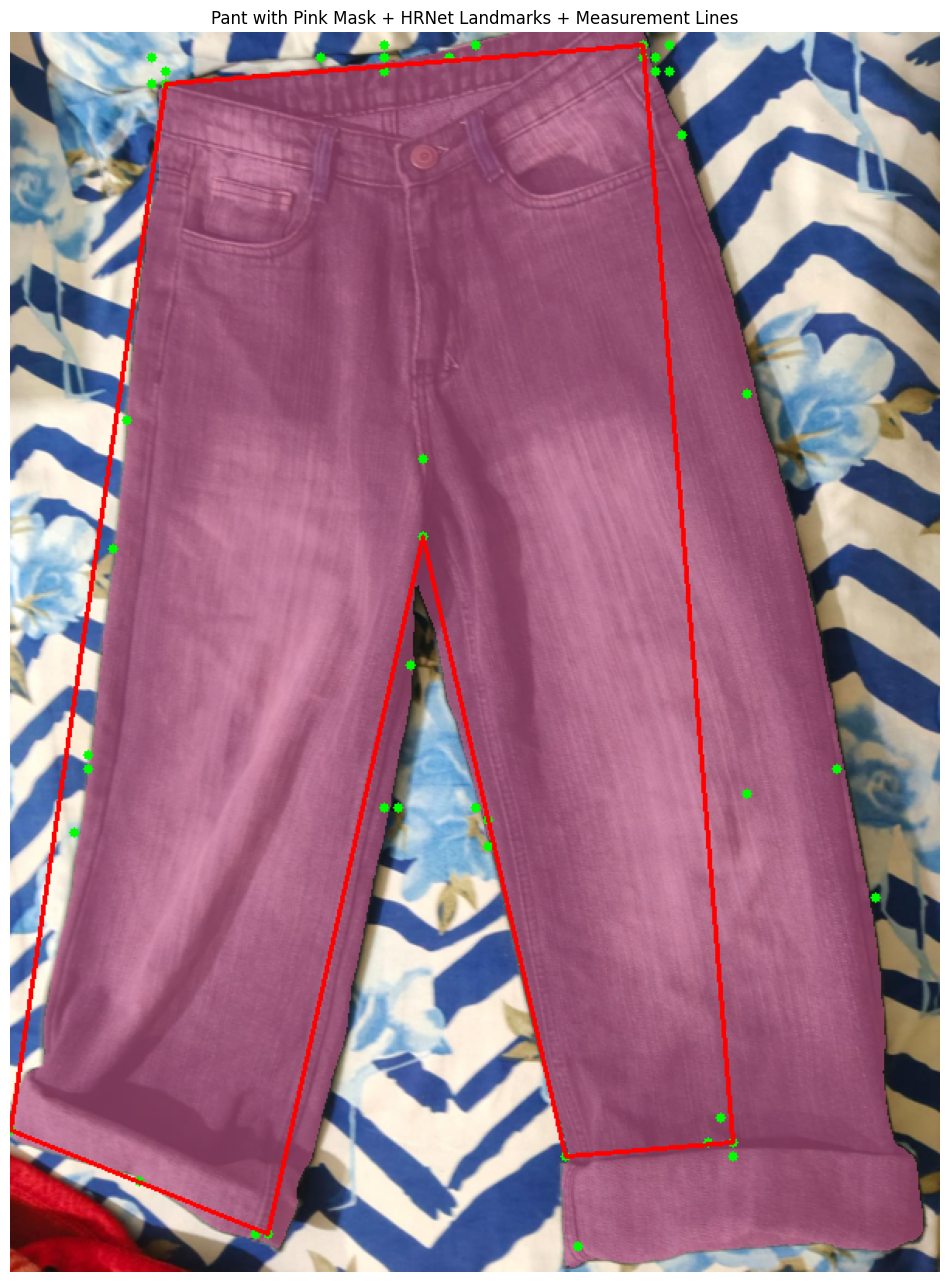


========== PIXEL MEASUREMENTS ==========
waist           = 309 px
outseam_left    = 676 px
outseam_right   = 709 px
ankle_left      = 167 px
ankle_right     = 109 px
inseam_left     = 451 px
inseam_right    = 401 px


In [21]:
# ======================================================
# SAM BG REMOVAL + HRNET + PINK MASK OVERLAY (FINAL)
# ======================================================

# -------------------------
# IMPORTS
# -------------------------
from PIL import Image
import numpy as np
import cv2
import sys, torch, argparse
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
IMAGE_PATH = "/content/drive/MyDrive/WhatsApp Image 2026-01-01 at 8.42.01 PM.jpeg"
PROMPT = "pant"
TARGET_SIZE = (600, 800)

HRNET_ROOT = "/content/HRNet-for-Fashion-Landmark-Estimation.PyTorch"
CFG_FILE   = f"{HRNET_ROOT}/experiments/deepfashion2/hrnet/w48_384x288_adam_lr1e-3.yaml"
MODEL_FILE = f"{HRNET_ROOT}/models/pose_hrnet-w48_384x288-deepfashion2_mAP_0.7017.pth"

# ======================================================
# 1️⃣ LOAD IMAGE
# ======================================================
image_pil = Image.open(IMAGE_PATH).convert("RGB").resize(TARGET_SIZE)
img_rgb = np.array(image_pil)
H, W = img_rgb.shape[:2]

# ======================================================
# 2️⃣ SAM SEGMENTATION (BG REMOVAL)
# ======================================================
inference_state = processor.set_image(image_pil)
inference_state = processor.set_text_prompt(state=inference_state, prompt=PROMPT)
detections = from_sam(sam_result=inference_state)

def extract_mask(det):
    if hasattr(det, "mask"):
        return np.asarray(det.mask)
    if isinstance(det, dict):
        for k in det:
            if "mask" in k:
                return np.asarray(det[k])
    if isinstance(det, (list, tuple)):
        for v in det:
            try:
                arr = np.asarray(v)
                if arr.ndim >= 2:
                    return arr
            except:
                pass
    return None

masks = []
for det in detections:
    m = extract_mask(det)
    if m is None:
        continue
    if m.ndim == 3:
        m = m[np.argmax(m.reshape(m.shape[0], -1).sum(axis=1))]
    m = cv2.resize(m.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
    masks.append(m > 0)

if not masks:
    raise RuntimeError("❌ SAM failed to extract pant mask")

best_mask = masks[np.argmax([m.sum() for m in masks])]

# ======================================================
# 3️⃣ CREATE PINK MASK OVERLAY
# ======================================================
PINK  = np.array([255, 105, 180], dtype=np.uint8)
ALPHA = 0.45

pink_overlay = np.zeros_like(img_rgb)
pink_overlay[:] = PINK

pink_masked_img = img_rgb.copy()
pink_masked_img[best_mask] = (
    (1 - ALPHA) * img_rgb[best_mask] +
    ALPHA * pink_overlay[best_mask]
).astype(np.uint8)

# ======================================================
# 4️⃣ HRNET SETUP (UNCHANGED)
# ======================================================
sys.path.append(f"{HRNET_ROOT}/lib")
from config import cfg, update_config
import models

args = argparse.Namespace(
    cfg=CFG_FILE,
    opts=[],
    modelDir='',
    logDir='',
    dataDir='',
    prevModelDir=''
)
update_config(cfg, args)

model = models.pose_hrnet.get_pose_net(cfg, is_train=False)
model.load_state_dict(torch.load(MODEL_FILE, map_location="cpu"), strict=False)
model.eval()

# HRNET INPUT (SAM OUTPUT USED)
# ======================================================
# 4️⃣ HRNET INPUT (USE PINK MASKED IMAGE)
# ======================================================
img = pink_masked_img.copy()   # 🔥 THIS IS THE KEY CHANGE

H, W = img.shape[:2]

inp = cv2.resize(img, (288, 384))
inp = inp.astype(np.float32) / 255.0
inp = inp.transpose(2, 0, 1)
inp = torch.from_numpy(inp).unsqueeze(0)


inp = cv2.resize(img, (288, 384)).astype(np.float32) / 255.0
inp = inp.transpose(2, 0, 1)
inp = torch.from_numpy(inp).unsqueeze(0)

with torch.no_grad():
    output = model(inp)

heatmaps = output.squeeze(0).cpu().numpy()
num_joints, hm_h, hm_w = heatmaps.shape

# ======================================================
# 5️⃣ EXTRACT KEYPOINTS
# ======================================================
points = []
for jid in range(num_joints):
    hm = heatmaps[jid]
    y, x = np.unravel_index(np.argmax(hm), hm.shape)
    x_img = int(x * W / hm_w)
    y_img = int(y * H / hm_h)
    points.append((jid, x_img, y_img))

POINT_DICT = {jid: (x, y) for jid, x, y in points}

# ======================================================
# 6️⃣ MANUAL INDICES (UNCHANGED)
# ======================================================
WAIST_L        = 101
WAIST_R        = 24
OUTER_ANKLE_L  = 14
OUTER_ANKLE_R  = 16
INNER_ANKLE_L  = 9
INNER_ANKLE_R  = 21
INSEAM         = 27

CONNECTIONS = [
    (WAIST_L, OUTER_ANKLE_L),
    (WAIST_R, OUTER_ANKLE_R),
    (WAIST_L, WAIST_R),
    (INNER_ANKLE_L, OUTER_ANKLE_L),
    (INNER_ANKLE_R, OUTER_ANKLE_R),
    (INNER_ANKLE_L, INSEAM),
    (INNER_ANKLE_R, INSEAM),
]

# ======================================================
# 7️⃣ DRAW VISUALS
# ======================================================
draw = pink_masked_img.copy()

for jid, (x, y) in POINT_DICT.items():
    cv2.circle(draw, (x, y), 3, (0, 255, 0), -1)

for a, b in CONNECTIONS:
    if a in POINT_DICT and b in POINT_DICT:
        cv2.line(draw, POINT_DICT[a], POINT_DICT[b], (255, 0, 0), 2)

plt.figure(figsize=(12, 18))
plt.imshow(draw)
plt.axis("off")
plt.title("Pant with Pink Mask + HRNet Landmarks + Measurement Lines")
plt.show()

# ======================================================
# 8️⃣ PIXEL MEASUREMENTS
# ======================================================
def count_line_pixels(p1, p2, shape):
    mask = np.zeros(shape[:2], dtype=np.uint8)
    cv2.line(mask, p1, p2, color=255, thickness=1)
    return int(np.count_nonzero(mask))

MEASUREMENTS = {
    "waist":            (WAIST_L, WAIST_R),
    "outseam_left":     (WAIST_L, OUTER_ANKLE_L),
    "outseam_right":    (WAIST_R, OUTER_ANKLE_R),
    "ankle_left":       (INNER_ANKLE_L, OUTER_ANKLE_L),
    "ankle_right":      (INNER_ANKLE_R, OUTER_ANKLE_R),
    "inseam_left":      (INNER_ANKLE_L, INSEAM),
    "inseam_right":     (INNER_ANKLE_R, INSEAM),
}

results = {}
for name, (a, b) in MEASUREMENTS.items():
    if a in POINT_DICT and b in POINT_DICT:
        results[name] = count_line_pixels(POINT_DICT[a], POINT_DICT[b], img.shape)
    else:
        results[name] = None

print("\n========== PIXEL MEASUREMENTS ==========")
for k, v in results.items():
    print(f"{k:15s} = {v if v is not None else '❌ missing'} px")


In [23]:
# ==============================
# 1️⃣ ASK USER FIRST
# ==============================
unit = "in"

user_input = input(
    "Enter waist size (FULL circumference).\n"
    "Press ENTER to skip: "
).strip()

c_val = float(user_input) if user_input != "" else None


# ==============================
# 2️⃣ EXTRACT PIXEL MEASUREMENTS
# ==============================
waist_px     = results.get("waist")

outseam_L_px = results.get("outseam_left")
outseam_R_px = results.get("outseam_right")

ankle_L_px   = results.get("ankle_left")
ankle_R_px   = results.get("ankle_right")

inseam_L_px  = results.get("inseam_left")
inseam_R_px  = results.get("inseam_right")


# ==============================
# 3️⃣ AVERAGE LEFT / RIGHT
# ==============================
def avg(a, b):
    return (a + b) / 2 if a is not None and b is not None else None

outseam_px = avg(outseam_L_px, outseam_R_px)
ankle_px   = avg(ankle_L_px, ankle_R_px)
inseam_px  = avg(inseam_L_px, inseam_R_px)


# ==============================
# 4️⃣ COMPUTE RATIOS (SAFE)
# ==============================
def safe_ratio(num, den):
    return num / den if num is not None and den is not None else None

ratio_waist_outseam = safe_ratio(outseam_px, waist_px)
ratio_waist_ankle   = safe_ratio(ankle_px, waist_px)
ratio_waist_inseam  = safe_ratio(inseam_px, waist_px)

print("\n----- RATIOS -----")
print("ratio waist → outseam :", ratio_waist_outseam)
print("ratio waist → ankle  :", ratio_waist_ankle)
print("ratio waist → inseam :", ratio_waist_inseam)



# ==============================
# 5️⃣ ESTIMATE REAL SIZES
# ==============================
if c_val is not None and waist_px is not None:

    half_waist = c_val / 2  # flat waist → half circumference

    est_outseam = (
        ratio_waist_outseam * half_waist - 2
        if ratio_waist_outseam is not None else None
    )

    est_ankle_L = (
        safe_ratio(ankle_L_px, waist_px) * half_waist
        if ankle_L_px is not None else None
    )

    est_ankle_R = (
        safe_ratio(ankle_R_px, waist_px) * half_waist
        if ankle_R_px is not None else None
    )

    est_inseam_L = (
        safe_ratio(inseam_L_px, waist_px) * half_waist
        if inseam_L_px is not None else None
    )

    est_inseam_R = (
        safe_ratio(inseam_R_px, waist_px) * half_waist
        if inseam_R_px is not None else None
    )

    print(f"\n----- ESTIMATES (based on waist = {c_val} {unit}) -----")

    if est_outseam is not None:
        print(f"outseam (avg)  : {est_outseam:.2f} {unit}")

    if est_ankle_L is not None:
        print(f"ankle left     : {est_ankle_L:.2f} {unit}")
    if est_ankle_R is not None:
        print(f"ankle right    : {est_ankle_R:.2f} {unit}")

    if est_inseam_L is not None:
        print(f"inseam left    : {est_inseam_L:.2f} {unit}")
    if est_inseam_R is not None:
        print(f"inseam right   : {est_inseam_R:.2f} {unit}")

else:
    print("\nNo waist entered — skipping real-unit estimates.")



Enter waist size (FULL circumference).
Press ENTER to skip: 30

----- RATIOS -----
ratio waist → outseam : 2.2411003236245954
ratio waist → ankle  : 0.44660194174757284
ratio waist → inseam : 1.3786407766990292

----- ESTIMATES (based on waist = 30.0 in) -----
outseam (avg)  : 31.62 in
ankle left     : 8.11 in
ankle right    : 5.29 in
inseam left    : 21.89 in
inseam right   : 19.47 in
